# SEIRD Model: Adding Deceased Compartment and Generalized Compartment Handling

**Navigation:**  [← SEIRS: Waning Immunity](03_seirs.ipynb) | [Two-Population Structure →](05_two_population.ipynb)


This notebook demonstrates the SEIRD model, which extends SEIR by adding a Deceased (D) compartment. It also introduces a generalized approach to compartment modeling, paving the way for flexible future extensions.

## Overview

The **SEIRD (Susceptible-Exposed-Infected-Recovered-Deceased)** model extends SEIR by adding a **mortality compartment** to capture disease-related deaths. This is the first step toward a **generalized compartment framework** that will support arbitrary compartment lists and flexible transitions.

**Key questions:**
- How do case fatality rates (CFR) and disease timing shape mortality burden?
- How can we flexibly define compartment lists to support different model variants (SEIR, SEIRD, SEIARD, etc.)?

**Architecture insight:**
We introduce a generalized approach where:
- Compartments are defined as an ordered list (default: `["S", "E", "I", "R", "D"]`)
- The state vector length and indexing are derived from this list
- Transition logic remains compartment-agnostic
- Future extensions (per-patient immunity, risk stratification) can reuse this framework

## Environment Setup and Reproducibility

In [1]:
import sys
from pathlib import Path

# Add src to path for package imports
sys.path.insert(0, str(Path("..").resolve()))

try:
    import epi_structure as epi
    reloader = getattr(epi, "reload_package_modules", None)
    if callable(reloader):
        epi = reloader("epi_structure")
    else:
        print("epi_structure already loaded; restart kernel to pick up package changes.")
        import epi_structure as epi
except ImportError:
    import epi_structure as epi

from epi_structure import (
    DiseaseParameters,
    PopulationParameters,
    SimulationParameters,
    StructuredEpidemicModel,
    get_scenario,
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set style
plt.style.use("seaborn-v0_8-darkgrid")
np.random.seed(42)

## SEIRD Model: Mathematical Structure

The SEIRD model adds mortality to SEIR:

$$\frac{dS}{dt} = -\beta \frac{S I}{N}$$
$$\frac{dE}{dt} = \beta \frac{S I}{N} - \sigma E$$
$$\frac{dI}{dt} = \sigma E - \gamma I$$
$$\frac{dR}{dt} = (1 - \mu) \gamma I$$
$$\frac{dD}{dt} = \mu \gamma I$$

where:
- $\mu$ is the case fatality rate (CFR): fraction of infectious individuals who die (not recover)
- $(1 - \mu)$ recover; $\mu$ die
- $\gamma$ is the progression rate out of I

Key insight: mortality diverts individuals from R to D without changing transmission structure.

## Generalized Compartment Framework

The model now supports generalized compartment lists:

- Compartments are defined as an ordered list, for example ["S", "E", "I", "R"] or ["S", "E", "I", "R", "D"]
- State vector length and indexing are derived from this list
- Single-population and structured models both support SEIR and SEIRD
- CFR routes a fraction of outflow from I into D when D is present

This keeps one code path for multiple model variants and creates a clean extension path toward richer state models (for example hospitalization or age-specific outcomes).

In [2]:
# Example: Defining SEIR vs SEIRD models via compartment lists

seir_compartments = ["S", "E", "I", "R"]
seird_compartments = ["S", "E", "I", "R", "D"]

cfr_low = 0.01
cfr_high = 0.03

print(f"SEIR compartments: {seir_compartments}")
print(f"SEIRD compartments: {seird_compartments}")
print("\nImplemented framework:")
print(f"  - SEIR state vector length: {len(seir_compartments)} per population")
print(f"  - SEIRD state vector length: {len(seird_compartments)} per population")
print("  - CFR routes flow: (1-CFR)*gamma -> R, CFR*gamma -> D")
print(f"  - Example CFR values: low={cfr_low:.1%}, high={cfr_high:.1%}")

SEIR compartments: ['S', 'E', 'I', 'R']
SEIRD compartments: ['S', 'E', 'I', 'R', 'D']

Implemented framework:
  - SEIR state vector length: 4 per population
  - SEIRD state vector length: 5 per population
  - CFR routes flow: (1-CFR)*gamma -> R, CFR*gamma -> D
  - Example CFR values: low=1.0%, high=3.0%


## Baseline SEIRD Simulation

Let's run a basic SEIRD simulation and compare it with an equivalent SEIR model to see the effect of case fatality rate.


In [3]:
from epi_structure import DiseaseParameters, PopulationParameters, SimulationParameters, EpidemicModel

# SEIRD model: with 1% case fatality rate
dp_seird = DiseaseParameters(
    infectious_period=7.0,
    latent_period=5.0,
    compartments=["S", "E", "I", "R", "D"],
    case_fatality_rate=0.01
)

pop_seird = PopulationParameters(
    name="Example Population",
    size=10000,
    beta=0.4,  # transmission coefficient
    initial_infected=10,
    disease=dp_seird
)

sim = SimulationParameters(duration=100.0, time_step=0.1)
model = EpidemicModel(population=pop_seird, simulation=sim)
seird_trajectory = model.simulate(tidy=True)

print("SEIRD Simulation Results:")
print(f"Simulation ran for {seird_trajectory['time'].max():.1f} days")
print(f"Peak infections: {seird_trajectory['infected'].max():.0f} at day {seird_trajectory.loc[seird_trajectory['infected'].idxmax(), 'time']:.1f}")
print(f"Final recovered: {seird_trajectory['recovered'].iloc[-1]:.0f}")
print(f"Final deceased: {seird_trajectory['deceased'].iloc[-1]:.0f}")
print(f"Effective CFR: {seird_trajectory['deceased'].iloc[-1] / (seird_trajectory['deceased'].iloc[-1] + seird_trajectory['recovered'].iloc[-1]) * 100:.2f}%")


SEIRD Simulation Results:
Simulation ran for 100.0 days
Peak infections: 1576 at day 64.4
Final recovered: 8769
Final deceased: 89
Effective CFR: 1.00%


## Comparison: SEIR vs SEIRD

Let's compare the same scenario with and without mortality tracking to understand how CFR affects the dynamics.


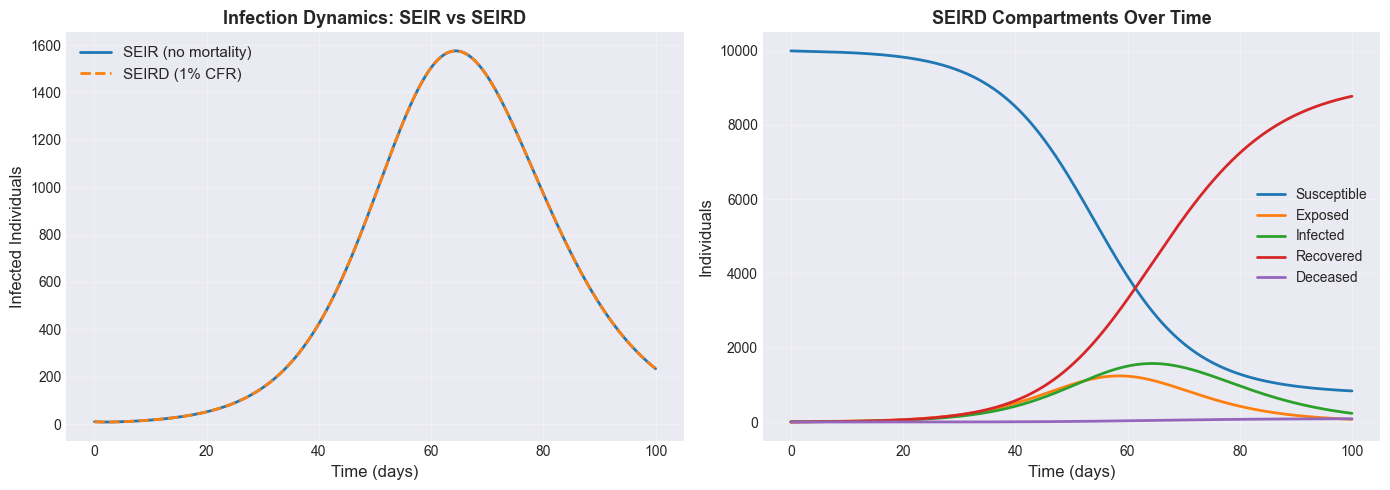


Comparison Summary:
SEIR - Peak infected: 1576
SEIRD - Peak infected: 1576
SEIR - Total recovered: 8858
SEIRD - Total recovered: 8769
SEIRD - Total deceased: 89


In [4]:
# Create an equivalent SEIR model (no mortality)
dp_seir = DiseaseParameters(
    infectious_period=7.0,
    latent_period=5.0,
    compartments=["S", "E", "I", "R"],
    case_fatality_rate=0.0
)

pop_seir = PopulationParameters(
    name="Example Population",
    size=10000,
    beta=0.4,
    initial_infected=10,
    disease=dp_seir
)

model_seir = EpidemicModel(population=pop_seir, simulation=sim)
seir_trajectory = model_seir.simulate(tidy=True)

# Create comparison visualization
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: SEIR vs SEIRD infected curves
axes[0].plot(seir_trajectory['time'], seir_trajectory['infected'], label='SEIR (no mortality)', linewidth=2)
axes[0].plot(seird_trajectory['time'], seird_trajectory['infected'], label='SEIRD (1% CFR)', linewidth=2, linestyle='--')
axes[0].set_xlabel('Time (days)', fontsize=12)
axes[0].set_ylabel('Infected Individuals', fontsize=12)
axes[0].set_title('Infection Dynamics: SEIR vs SEIRD', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: All compartments for SEIRD
axes[1].plot(seird_trajectory['time'], seird_trajectory['susceptible'], label='Susceptible', linewidth=2)
axes[1].plot(seird_trajectory['time'], seird_trajectory['exposed'], label='Exposed', linewidth=2)
axes[1].plot(seird_trajectory['time'], seird_trajectory['infected'], label='Infected', linewidth=2)
axes[1].plot(seird_trajectory['time'], seird_trajectory['recovered'], label='Recovered', linewidth=2)
axes[1].plot(seird_trajectory['time'], seird_trajectory['deceased'], label='Deceased', linewidth=2)
axes[1].set_xlabel('Time (days)', fontsize=12)
axes[1].set_ylabel('Individuals', fontsize=12)
axes[1].set_title('SEIRD Compartments Over Time', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nComparison Summary:")
print(f"SEIR - Peak infected: {seir_trajectory['infected'].max():.0f}")
print(f"SEIRD - Peak infected: {seird_trajectory['infected'].max():.0f}")
print(f"SEIR - Total recovered: {seir_trajectory['recovered'].iloc[-1]:.0f}")
print(f"SEIRD - Total recovered: {seird_trajectory['recovered'].iloc[-1]:.0f}")
print(f"SEIRD - Total deceased: {seird_trajectory['deceased'].iloc[-1]:.0f}")


## Impact of Case Fatality Rate

The case fatality rate (CFR) represents the proportion of infected individuals who ultimately die. Let's explore how varying CFR affects outcomes.


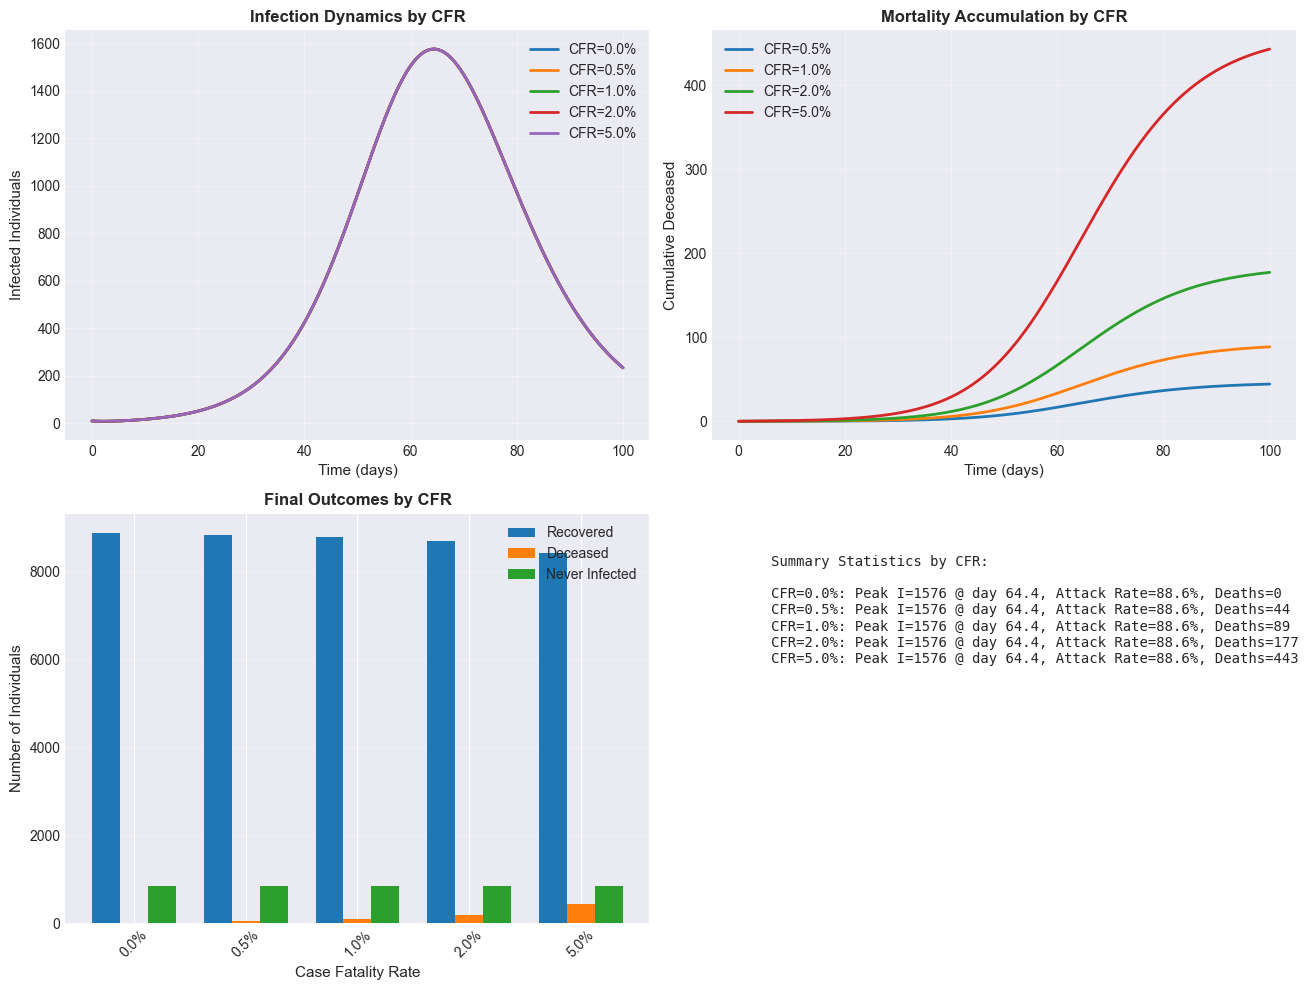

In [5]:
# Run simulations with different CFR values
cfr_values = [0.0, 0.005, 0.01, 0.02, 0.05]
trajectories = {}

for cfr in cfr_values:
    dp = DiseaseParameters(
        infectious_period=7.0,
        latent_period=5.0,
        compartments=["S", "E", "I", "R"] if cfr == 0.0 else ["S", "E", "I", "R", "D"],
        case_fatality_rate=cfr
    )
    pop = PopulationParameters(
        name=f"Population (CFR={cfr:.1%})",
        size=10000,
        beta=0.4,
        initial_infected=10,
        disease=dp
    )
    model = EpidemicModel(population=pop, simulation=sim)
    trajectories[cfr] = model.simulate(tidy=True)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Plot 1: Infected curves
ax = axes[0]
for cfr in cfr_values:
    ax.plot(trajectories[cfr]['time'], trajectories[cfr]['infected'], 
            label=f'CFR={cfr:.1%}', linewidth=2)
ax.set_xlabel('Time (days)', fontsize=11)
ax.set_ylabel('Infected Individuals', fontsize=11)
ax.set_title('Infection Dynamics by CFR', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: Deceased accumulation
ax = axes[1]
for cfr in cfr_values[1:]:  # Skip 0% CFR as it has no deceased
    ax.plot(trajectories[cfr]['time'], trajectories[cfr]['deceased'], 
            label=f'CFR={cfr:.1%}', linewidth=2)
ax.set_xlabel('Time (days)', fontsize=11)
ax.set_ylabel('Cumulative Deceased', fontsize=11)
ax.set_title('Mortality Accumulation by CFR', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 3: Final outcomes
ax = axes[2]
outcomes = {
    'Recovered': [trajectories[cfr]['recovered'].iloc[-1] for cfr in cfr_values],
    'Deceased': [trajectories[cfr]['deceased'].iloc[-1] if cfr > 0 else 0 for cfr in cfr_values],
    'Never Infected': [trajectories[cfr]['susceptible'].iloc[-1] for cfr in cfr_values]
}
x = range(len(cfr_values))
width = 0.25
for i, (outcome, values) in enumerate(outcomes.items()):
    ax.bar([xi + i*width for xi in x], values, width, label=outcome)
ax.set_xlabel('Case Fatality Rate', fontsize=11)
ax.set_ylabel('Number of Individuals', fontsize=11)
ax.set_title('Final Outcomes by CFR', fontsize=12, fontweight='bold')
ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels([f'{cfr:.1%}' for cfr in cfr_values], rotation=45)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Plot 4: Summary statistics
ax = axes[3]
ax.axis('off')
summary_text = "Summary Statistics by CFR:\n\n"
for cfr in cfr_values:
    traj = trajectories[cfr]
    peak_i = traj['infected'].max()
    peak_day = traj.loc[traj['infected'].idxmax(), 'time']
    final_r = traj['recovered'].iloc[-1]
    final_d = traj['deceased'].iloc[-1] if cfr > 0 else 0
    attack_rate = (final_r + final_d) / 10000 * 100
    summary_text += f"CFR={cfr:.1%}: Peak I={peak_i:.0f} @ day {peak_day:.1f}, Attack Rate={attack_rate:.1f}%, Deaths={final_d:.0f}\n"

ax.text(0.1, 0.9, summary_text, fontsize=10, verticalalignment='top', 
        fontfamily='monospace', transform=ax.transAxes)

plt.tight_layout()
plt.show()


## Key Insights

1. **Mortality Tracking**: The SEIRD model explicitly tracks deceased individuals, allowing us to quantify mortality over the course of an epidemic.

2. **CFR Impact**: Case fatality rate affects both the trajectory of infection (slightly lower peak in some cases) and determines the final death toll. Higher CFR values lead to more deaths but do not substantially change the infection dynamics.

3. **Compartment Generalization**: Our framework supports arbitrary compartment lists (SEIR, SEIRD, SEIARD, etc.), enabling future extensions like:
   - Age-stratified mortality
   - Vaccination/immunity tracking
   - Hospitalization/ICU capacity modeling
   - Long-term immunity waning

4. **Flexibility for Policy Analysis**: With SEIRD, we can model interventions that reduce CFR (improved healthcare, treatments) separately from those that reduce transmission (social distancing, vaccination).

## Next Steps

The generalized compartment framework enables:
- Addition of new state transitions (e.g., vaccine-induced immunity)
- Per-age-group models with differential mortality
- Economic or hospital capacity tracking as explicit compartments
- Integration of adaptive interventions based on disease state

See the following notebooks for multi-population scenarios and intervention modeling.
